In [28]:
import os
import pyarrow as pa

_NCPU = os.cpu_count() or 1
pa.set_cpu_count(_NCPU)
pa.set_io_thread_count(_NCPU)
os.environ["NUMEXPR_MAX_THREADS"] = str(_NCPU)
os.environ["NUMEXPR_NUM_THREADS"] = str(_NCPU)
os.environ.setdefault("OMP_NUM_THREADS", str(_NCPU))
os.environ.setdefault("OPENBLAS_NUM_THREADS", str(_NCPU))
os.environ.setdefault("MKL_NUM_THREADS", str(_NCPU))
print(f"Running with {_NCPU} CPU cores | pyarrow {pa.__version__}", flush=True)

Running with 96 CPU cores | pyarrow 24.0.0


In [29]:
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.feature_selection import mutual_info_regression
from tqdm import tqdm

pd.set_option('display.max_columns', None)


In [30]:
FEATURE_DATASET = "1_dispatch_price.parquet"
STATE = "NSW"

In [31]:
def load_features(
        features_path: Path,
        pipeline_start: pd.Timestamp,
        pipeline_end: pd.Timestamp,
) -> pd.DataFrame:
    features = pd.read_parquet(features_path, filters=[
        ('SETTLEMENTDATE', '>=', pipeline_start),
        ('SETTLEMENTDATE', '<=', pipeline_end),
    ])
    _TARGET_COLS = {"nsw_price", "qld_price", "sa_price", "vic_price", "price"}
    features = features.drop(columns=[c for c in features.columns if c in _TARGET_COLS])
    return features.loc[:pipeline_end]


def load_targets(state:str):
    future_prediction_targets = pd.read_parquet(f"../3_Targets build/Target_data/{state.lower()}_targets.parquet")
    return future_prediction_targets




# Make calls
features = load_features(
    features_path=Path(f"../2_Features build/Feature_data/{FEATURE_DATASET}"),   # Select future dataset
    pipeline_start=pd.Timestamp("2019/01/01"),
    pipeline_end=pd.Timestamp("2026/01/01"),
)

future_prediction_targets = load_targets(
    state=STATE     # select state
    )

# Align on index
future_prediction_targets = future_prediction_targets.loc[features.index]
features = features.loc[future_prediction_targets.index]

In [32]:
"""
Rank features

MI ranking: measures mutual information — a non-linear, information-theoretic score. It answers "does knowing this feature reduce uncertainty about the target?",
capturing non-linear dependencies too. Targets are pre-aggregated to output_resolution_minutes before scoring,
so MI is computed directly at the output resolution (96 × 30-min horizons).
"""

def rank_features(
    features: pd.DataFrame,
    future_prediction_targets: pd.DataFrame,
    feature_selection_subsample_start: pd.Timestamp,
    feature_selection_subsample_end: pd.Timestamp,
    mi_subsample: int = 20_000,
    output_resolution_minutes: int = 30,
) -> tuple[pd.Series, pd.DataFrame, np.ndarray, pd.DataFrame, list[str], list[str]]:
    # Runtime guide (96 output horizons, 638 features, 96 CPUs — 1 job per core):
    #   mi_subsample=  5_000 →  ~0.5 min  (fast, lower accuracy)
    #   mi_subsample= 20_000 →  ~2 min    (good balance)
    #   mi_subsample= 50_000 →  ~6 min    (high accuracy)
    #   mi_subsample=100_000 → ~12 min    (very high accuracy)

    from joblib import Parallel, delayed

    feature_cols = list(features.columns)
    target_cols  = list(future_prediction_targets.columns)
    horizons     = len(target_cols)

    def _filter_data_for_feature_time_range_subset():
        features_subset = features.loc[feature_selection_subsample_start:feature_selection_subsample_end]
        targets_subset  = future_prediction_targets.loc[feature_selection_subsample_start:feature_selection_subsample_end]
        shared_index    = features_subset.index.intersection(targets_subset.index)
        return features_subset.loc[shared_index], targets_subset.loc[shared_index]

    features_subset, targets_subset = _filter_data_for_feature_time_range_subset()

    features_subset = features_subset.values.astype(np.float32)
    targets_subset = targets_subset.reset_index(drop=True)

    def _subsample_features():
        seed = np.random.default_rng(42)
        n_samples = min(mi_subsample, len(features_subset))
        subsample_index = seed.choice(len(features_subset), size=n_samples, replace=False)
        subsample_index.sort()
        return features_subset[subsample_index], targets_subset.iloc[subsample_index]

    X_subsample, y_subsample = _subsample_features()

    def _mutual_information_scoring():
        # Pre-aggregate 5-min targets to output_resolution_minutes before scoring.
        # This scores MI directly at the output resolution, which is 6× fewer
        # computations than scoring 576 5-min horizons and aggregating afterwards.
        y_arr_5min = y_subsample[target_cols].values.astype(np.float32)  # (n, 576)
        n_features = X_subsample.shape[1]
        n          = X_subsample.shape[0]

        # Aggregate 5-min targets → output_resolution_minutes buckets
        bucket_size = max(1, output_resolution_minutes // 5)
        n_buckets   = horizons // bucket_size
        n_raw       = n_buckets * bucket_size
        # (n, n_buckets, bucket_size) → mean over last axis → (n, n_buckets)
        y_arr = y_arr_5min[:, :n_raw].reshape(n, n_buckets, bucket_size).mean(axis=2)
        bucket_cols = [f"h{i + 1}" for i in range(n_buckets)]

        # Split features into chunks so n_tasks >> n_workers → multiple rounds → smooth progress bar.
        # MI is a pairwise measure (each feature scored independently), so chunking features
        # has zero effect on results — only on how work is dispatched to workers.
        target_rounds = 10
        n_feat_chunks = max(1, (target_rounds * _NCPU + n_buckets - 1) // n_buckets)
        chunk_edges   = np.array_split(np.arange(n_features), n_feat_chunks)
        feat_chunks   = [(int(c[0]), int(c[-1]) + 1) for c in chunk_edges if len(c) > 0]
        n_tasks       = n_buckets * len(feat_chunks)

        print(
            f"  MI scoring: {n_features} features × {n_buckets} horizons ({output_resolution_minutes}-min) "
            f"| subsample n={n:,} | {n_tasks} tasks across {_NCPU} CPUs (~{n_tasks // _NCPU} rounds)",
            flush=True,
        )

        def _score_chunk(j, fs, fe):
            return j, fs, fe, mutual_info_regression(
                X_subsample[:, fs:fe], y_arr[:, j],
                discrete_features=False, n_neighbors=3, random_state=42,
            )

        gen = Parallel(n_jobs=-1, backend="loky", batch_size=1, return_as="generator_unordered")(
            delayed(_score_chunk)(j, fs, fe)
            for j in range(n_buckets) for fs, fe in feat_chunks
        )
        scores = np.empty((n_features, n_buckets))
        for j, fs, fe, chunk_scores in tqdm(gen, total=n_tasks, desc="MI scoring", leave=True):
            scores[fs:fe, j] = chunk_scores

        mi_matrix = pd.DataFrame(scores, index=feature_cols, columns=bucket_cols)
        feature_cols_ranked = mi_matrix.mean(axis=1).sort_values(ascending=False)
        return feature_cols_ranked, mi_matrix

    feature_cols_ranked, mi_matrix = _mutual_information_scoring()

    return feature_cols_ranked, mi_matrix, features_subset, targets_subset, feature_cols, target_cols


feature_cols_ranked, mi_matrix, features_subset, targets_subset, feature_cols, target_cols = rank_features(
    features=features,
    future_prediction_targets=future_prediction_targets,
    feature_selection_subsample_start=pd.Timestamp("2019/01/01"),
    feature_selection_subsample_end=pd.Timestamp("2023/01/01"),
    mi_subsample=1_000,
    output_resolution_minutes=30,     # scores 96 × 30-min horizons directly (mean of 6 adjacent 5-min targets)
)

print(f"Ranked all {len(feature_cols_ranked)} provided features.")


  MI scoring: 634 features × 96 horizons (30-min) | subsample n=1,000 | 960 tasks across 96 CPUs (~10 rounds)


MI scoring: 100%|██████████| 960/960 [00:07<00:00, 127.74it/s]

Ranked all 634 provided features.


In [50]:
dataset_stem = Path(FEATURE_DATASET).stem

# Base ranking columns + per-horizon MI scores (h1…h96) as additional columns
ranked_path = f"Selected_features/{STATE}_{dataset_stem}_feature_ranking.parquet"
df_base = pd.DataFrame({
    "rank":            range(1, len(feature_cols_ranked) + 1),
    "feature":         feature_cols_ranked.index,
    "mean_mi":         feature_cols_ranked.values,
    "state":           STATE,
    "feature_dataset": dataset_stem,
}).set_index("feature")

# mi_matrix rows = features (same order as feature_cols_ranked after reindex)
df_horizons = mi_matrix.reindex(feature_cols_ranked.index)

df_ranking = pd.concat([df_base, df_horizons], axis=1).reset_index(names="feature")
df_ranking.to_parquet(ranked_path, index=False)

print(f"Saved {len(df_ranking)} features × {len(mi_matrix.columns)} horizons → {ranked_path}")


Saved 634 features × 96 horizons → Selected_features/NSW_1_dispatch_price_feature_ranking.parquet


In [51]:
df = pd.read_parquet(f"Selected_features/{STATE}_{dataset_stem}_feature_ranking.parquet")
df[:10]

,feature,rank,mean_mi,state,feature_dataset,h1,h2,h3,h4,h5,h6,h7,h8,h9,h10,h11,h12,h13,h14,h15,h16,h17,h18,h19,h20,h21,h22,h23,h24,h25,h26,h27,h28,h29,h30,h31,h32,h33,h34,h35,h36,h37,h38,h39,h40,h41,h42,h43,h44,h45,h46,h47,h48,h49,h50,h51,h52,h53,h54,h55,h56,h57,h58,h59,h60,h61,h62,h63,h64,h65,h66,h67,h68,h69,h70,h71,h72,h73,h74,h75,h76,h77,h78,h79,h80,h81,h82,h83,h84,h85,h86,h87,h88,h89,h90,h91,h92,h93,h94,h95,h96
0,nsw_price_q90_336,1,0.520367,NSW,1_dispatch_price,0.639766,0.585509,0.609695,0.620592,0.582991,0.576197,0.568062,0.563819,0.560152,0.526092,0.552341,0.530139,0.528438,0.464970,0.531449,0.534522,0.535162,0.528518,0.600189,0.537620,0.544512,0.611068,0.549736,0.607095,0.597167,0.506454,0.508157,0.528274,0.472219,0.485082,0.463782,0.453339,0.475271,0.472956,0.509012,0.561253,0.560898,0.552487,0.560784,0.567091,0.605992,0.587929,0.605386,0.553365,0.585876,0.578331,0.594820,0.554000,0.490541,0.552382,0.562166,0.534343,0.467525,0.486299,0.451990,0.485467,0.488296,0.428046,0.445112,0.479345,0.466278,0.458642,0.464035,0.436112,0.419341,0.499857,0.502023,0.492242,0.554230,0.506292,0.470098,0.476254,0.506286,0.482143,0.454740,0.439283,0.418425,0.418859,0.483277,0.473147,0.481112,0.454074,0.533918,0.519957,0.580318,0.531698,0.485760,0.490645,0.502714,0.536959,0.517235,0.537621,0.533226,0.514806,0.507854,0.505714
1,nsw_price_asinh_rmean_336,2,0.508457,NSW,1_dispatch_price,0.669668,0.601920,0.612534,0.636281,0.627400,0.601567,0.624224,0.540811,0.537632,0.523939,0.526626,0.527934,0.514671,0.525278,0.517664,0.516195,0.486623,0.531660,0.556299,0.523825,0.540229,0.512724,0.565422,0.523272,0.551111,0.512797,0.484811,0.512637,0.470028,0.464717,0.450288,0.460500,0.489705,0.546980,0.546631,0.575655,0.524799,0.536079,0.551488,0.537154,0.582216,0.593880,0.580602,0.556457,0.543631,0.570113,0.535440,0.577510,0.475813,0.491969,0.485420,0.506332,0.470341,0.498873,0.474476,0.459533,0.452788,0.479713,0.437834,0.421766,0.426041,0.451613,0.457722,0.462982,0.475821,0.492980,0.487037,0.483651,0.539279,0.481138,0.457238,0.489295,0.422522,0.492058,0.445113,0.442738,0.428636,0.399256,0.420610,0.463200,0.456595,0.436282,0.497134,0.475553,0.483733,0.448766,0.499841,0.500438,0.471376,0.495269,0.492289,0.545606,0.504920,0.498430,0.510044,0.522200
2,nsw_price_rmean_2016,3,0.496087,NSW,1_dispatch_price,0.527689,0.566931,0.505186,0.549046,0.533929,0.547354,0.498999,0.514184,0.565817,0.535580,0.503777,0.527859,0.483552,0.513701,0.499600,0.539287,0.548703,0.513125,0.533715,0.574611,0.527763,0.513766,0.524695,0.505945,0.508257,0.507750,0.471431,0.508754,0.497336,0.495440,0.452167,0.401541,0.453020,0.511102,0.453084,0.491286,0.521304,0.485608,0.501109,0.468756,0.525776,0.540875,0.527598,0.474595,0.534144,0.486363,0.509003,0.469705,0.433704,0.443740,0.477701,0.517562,0.453206,0.534580,0.483386,0.472560,0.472733,0.459443,0.428083,0.497421,0.447383,0.485964,0.456664,0.471321,0.496966,0.544277,0.481334,0.512906,0.527601,0.497474,0.456383,0.532066,0.475015,0.458292,0.459867,0.447893,0.506253,0.442617,0.475158,0.490255,0.442541,0.500104,0.500882,0.495819,0.490455,0.519124,0.523606,0.492460,0.485441,0.473860,0.505556,0.482530,0.471714,0.476842,0.479530,0.493238
3,nsw_price_rmean_336,4,0.474657,NSW,1_dispatch_price,0.657172,0.586954,0.579340,0.596623,0.551995,0.577307,0.562943,0.477005,0.491564,0.496701,0.501393,0.480718,0.454702,0.502515,0.482148,0.456029,0.486751,0.501782,0.498066,0.496577,0.487750,0.482443,0.491294,0.509372,0.564814,0.481812,0.504632,0.474702,0.427545,0.435335,0.434403,0.456559,0.438363,0.497473,0.500490,0.503864,0.523297,0.520139,0.531438,0.497326,0.557172,0.575362,0.519130,0.517431,0.538631,0.508878,0.492301,0.500819,0.465467,0.471322,0.495367,0.484133,0.457836,0.454444,0.444604,0.422700,0.426260,0.404515,0.431449,0.419650,0.393302,0.384979,0.394534,0.415234,0.428442,0.486852,0.434582,0.448540,0.485006,0.424201,0.404562,0.458099,0.392744,0.457079,0.445864,0.429143,0.392435,0.382612,0.406104,0.429181,0.437223,0.392176,0.439278,0.453144,0.477892,0.4

In [60]:
HORIZONS_PER_WINDOW = 8          # 8 × 30 min = 4 h
N_WINDOWS = len(mi_matrix.columns) // HORIZONS_PER_WINDOW   # 12

horizon_cols = list(mi_matrix.columns)   # h1 … h96

# Pre-compute normalised feature matrix once — reused across all 12 windows
_feat_mean = features_subset.mean(axis=0, keepdims=True)
_feat_std  = features_subset.std(axis=0, keepdims=True) + 1e-8
_feat_norm = (features_subset - _feat_mean) / _feat_std
_feat_idx  = {name: idx for idx, name in enumerate(feature_cols)}


def _window_unique_features(ranked_window: pd.Series, corr_threshold: float = 0.80) -> list[str]:
    """Greedy Pearson dedup using only the MI ranking for a single 4-h window."""
    unique: list[str] = []
    selected_vecs = None
    for feat, _ in ranked_window.items():
        vec = _feat_norm[:, _feat_idx[feat]]
        if selected_vecs is not None:
            if np.abs(selected_vecs @ vec).max() / len(vec) > corr_threshold:
                continue
            selected_vecs = np.vstack([selected_vecs, vec[np.newaxis, :]])
        else:
            selected_vecs = vec[np.newaxis, :]
        unique.append(feat)
    return unique or list(ranked_window.index)


window_selections  = {}   # label → ranked + deduped feature list for that window
window_mi_matrices = {}   # label → mi_matrix slice (n_features × 8 horizons)

for w in range(N_WINDOWS):
    col_start     = w * HORIZONS_PER_WINDOW
    col_end       = col_start + HORIZONS_PER_WINDOW
    label         = f"h{col_start + 1:02d}_h{col_end:02d}"   # h01_h08 … h89_h96

    win_cols      = horizon_cols[col_start:col_end]
    mi_window     = mi_matrix[win_cols]
    ranked_window = mi_window.mean(axis=1).sort_values(ascending=False)
    selected      = _window_unique_features(ranked_window)

    window_mi_matrices[label] = mi_window
    window_selections[label]  = selected

    print(f"  {label}: {len(selected):3d} unique features")

print(f"\n{N_WINDOWS} windows × {HORIZONS_PER_WINDOW} horizons (4 h each) — per-window selections ready.")


  h01_h08: 419 unique features
  h09_h16: 424 unique features
  h17_h24: 423 unique features
  h25_h32: 425 unique features
  h33_h40: 421 unique features
  h41_h48: 424 unique features
  h49_h56: 421 unique features
  h57_h64: 420 unique features
  h65_h72: 421 unique features
  h73_h80: 419 unique features
  h81_h88: 424 unique features
  h89_h96: 424 unique features

12 windows × 8 horizons (4 h each) — per-window selections ready.


In [63]:
# Build per-window feature groupings parquet
# Columns: window, window_start_h, window_end_h, rank_in_window, feature, mean_mi_window
rows = []
for label, feats in window_selections.items():
    start_h, end_h = label.split("_")   # e.g. "h01", "h08"
    ranked_window = window_mi_matrices[label].mean(axis=1)
    for rank, feat in enumerate(feats, start=1):
        rows.append({
            "window":          label,
            "window_start_h":  start_h,
            "window_end_h":    end_h,
            "rank_in_window":  rank,
            "feature":         feat,
            "mean_mi_window":  float(ranked_window.loc[feat]),
            "state":           STATE,
            "feature_dataset": dataset_stem,
        })

df_windows = pd.DataFrame(rows)
windows_path = f"Selected_features/{STATE}_{dataset_stem}_window_features.parquet"
df_windows.to_parquet(windows_path, index=False)
print(f"Saved {len(df_windows)} rows ({N_WINDOWS} windows) → {windows_path}")

Saved 5065 rows (12 windows) → Selected_features/NSW_1_dispatch_price_window_features.parquet


In [67]:
df_windows = pd.read_parquet(f"Selected_features/{STATE}_{dataset_stem}_window_features.parquet")
df_windows[:10]

,window,window_start_h,window_end_h,rank_in_window,feature,mean_mi_window,state,feature_dataset
0,h01_h08,h01,h08,1,nsw_price_rmean_4,0.852250,NSW,1_dispatch_price
1,h01_h08,h01,h08,2,nsw_price_asinh_lag_1,0.817918,NSW,1_dispatch_price
2,h01_h08,h01,h08,3,nsw_price_rmin_4,0.790653,NSW,1_dispatch_price
3,h01_h08,h01,h08,4,nsw_price_rmax_8,0.728991,NSW,1_dispatch_price
4,h01_h08,h01,h08,5,nsw_price_lag_4,0.724098,NSW,1_dispatch_price
5,h01_h08,h01,h08,6,nsw_price_lag_3,0.710069,NSW,1_dispatch_price
6,h01_h08,h01,h08,7,nsw_price_lag_6,0.695516,NSW,1_dispatch_price
7,h01_h08,h01,h08,8,nsw_price_rmean_24,0.694381,NSW,1_dispatch_price
8,h01_h08,h01,h08,9,nsw_price_rmin_24,0.661166,NSW,1_dispatch_price
9,h01_h08,h01,h08,10,nsw_price_lag_8,0.651413,NSW,1_dispatch_price


In [76]:
def mi_matrix_facets(window_selections: dict, window_mi_matrices: dict, top_n: int = 20, ncols: int = 4):
    """All 12 window MI heatmaps in one faceted figure with a shared colorbar."""
    labels = list(window_selections.keys())
    nrows  = (len(labels) + ncols - 1) // ncols

    _cmap = LinearSegmentedColormap.from_list(
        "mi_vibrant", ["#0a0a1a", "#2e1a6e", "#7b2d8b", "#d63a6e", "#f4845f"], N=256
    )

    # Pre-normalise each window's MI matrix, sorted by window MI, top_n features
    win_norms = {}
    for label, feats in window_selections.items():
        mi_win = window_mi_matrices[label].loc[feats]
        mi_win = mi_win.loc[mi_win.mean(axis=1).sort_values(ascending=False).index]
        win_norms[label] = (1 - np.exp(-mi_win)).head(top_n)

    col_w   = 6
    row_h   = max(4.0, top_n * 0.32)
    CBAR_H  = 0.5

    with plt.style.context("dark_background"):
        fig = plt.figure(figsize=(col_w * ncols, row_h * nrows + CBAR_H))
        fig.patch.set_facecolor("#1e1e1e")

        gs = fig.add_gridspec(
            nrows + 1, ncols,
            height_ratios=[CBAR_H] + [row_h] * nrows,
            hspace=0.45, wspace=0.35,
        )
        cax = fig.add_subplot(gs[0, :])

        for idx, label in enumerate(labels):
            r = idx // ncols + 1
            c = idx % ncols
            ax = fig.add_subplot(gs[r, c])
            ax.set_facecolor("#1e1e1e")

            data       = win_norms[label]
            n_feat     = data.shape[0]
            annot_size = max(5, min(9, int(160 / max(n_feat, 1))))
            y_size     = max(6, min(9, int(200 / max(n_feat, 1))))

            sns.heatmap(
                data, ax=ax, cmap=_cmap, vmin=0, vmax=1,
                annot=True, fmt=".2f",
                annot_kws={"size": annot_size, "color": "white"},
                linewidths=0, linecolor="#2e2e2e", cbar=False,
            )
            ax.set_title(label, color="white", fontsize=10, pad=4)
            ax.xaxis.set_ticks_position("top")
            ax.xaxis.set_label_position("top")
            ax.tick_params(axis="x", labelsize=7, rotation=45, colors="white")
            ax.tick_params(axis="y", labelsize=y_size, rotation=0, colors="white")
            plt.setp(ax.get_xticklabels(), ha="left")

        # Shared colorbar in the top strip
        sm   = plt.cm.ScalarMappable(cmap=_cmap, norm=plt.Normalize(vmin=0, vmax=1))
        cbar = fig.colorbar(sm, cax=cax, orientation="horizontal")
        cax.xaxis.set_ticks_position("top")
        cax.xaxis.set_label_position("top")
        cbar.set_label("MI  (1 − e⁻ᴹᴵ)  —  normalised per feature", color="white", labelpad=6)
        cbar.ax.tick_params(colors="white")

        fig.suptitle(
            f"Feature–target MI by 4-hour window  (top {top_n} features per window)",
            color="white", fontsize=14, y=1.0,
        )
        plt.show()


def plot_cumulative_mi_elbow(mi_matrix_normalised: pd.DataFrame, title: str = "Cumulative MI") -> int:
    mean_mi = mi_matrix_normalised.mean(axis=1).sort_values(ascending=False).values
    cumulative_mi = np.cumsum(mean_mi)
    total_mi = cumulative_mi[-1]
    ranks = np.arange(1, len(mean_mi) + 1)

    x_norm    = ranks / ranks[-1]
    y_norm    = cumulative_mi / total_mi
    line_vec  = np.array([x_norm[-1] - x_norm[0], y_norm[-1] - y_norm[0]])
    line_vec  = line_vec / np.linalg.norm(line_vec)
    point_vec = np.column_stack([x_norm - x_norm[0], y_norm - y_norm[0]])
    perp_dist = np.abs(point_vec @ np.array([-line_vec[1], line_vec[0]]))
    elbow_idx = int(np.argmax(perp_dist))
    elbow_rank = elbow_idx + 1
    pct_captured = 100 * cumulative_mi[elbow_idx] / total_mi

    with plt.style.context("dark_background"):
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
        fig.patch.set_facecolor("#1e1e1e")
        fig.suptitle(title, color="white", fontsize=13)
        for ax in (ax1, ax2):
            ax.set_facecolor("#1e1e1e")

        ax1.plot(ranks, cumulative_mi / total_mi * 100, color="#d63a6e", linewidth=1.5)
        ax1.axvline(elbow_rank, color="#f4845f", linestyle="--", linewidth=1.5,
                    label=f"Elbow @ rank {elbow_rank}  ({pct_captured:.1f}%)")
        ax1.set_xlabel("Feature rank", color="white")
        ax1.set_ylabel("Cumulative MI (%)", color="white")
        ax1.set_title("Cumulative MI", color="white", fontsize=11)
        ax1.tick_params(colors="white")
        ax1.legend(framealpha=0.2, labelcolor="white")
        ax1.spines[["top", "right"]].set_visible(False)
        for spine in ax1.spines.values(): spine.set_edgecolor("#555")

        ax2.bar(ranks, mean_mi, color="#2e1a6e", width=1.0)
        ax2.axvline(elbow_rank, color="#f4845f", linestyle="--", linewidth=1.5,
                    label=f"Elbow @ rank {elbow_rank}")
        ax2.set_xlabel("Feature rank", color="white")
        ax2.set_ylabel("Mean MI  (1 − e⁻ᴹᴵ)", color="white")
        ax2.set_title("Marginal MI per feature", color="white", fontsize=11)
        ax2.tick_params(colors="white")
        ax2.legend(framealpha=0.2, labelcolor="white")
        ax2.spines[["top", "right"]].set_visible(False)
        for spine in ax2.spines.values(): spine.set_edgecolor("#555")

        plt.tight_layout()
        plt.show()

    print(f"  Elbow @ rank {elbow_rank} ({pct_captured:.1f}% of total MI)")
    return elbow_rank


def plot_validation_curve(
    features: pd.DataFrame,
    targets: pd.DataFrame,
    mi_matrix_normalised: pd.DataFrame,
    elbow_rank: int,
    k_values: list[int] | None = None,
    n_splits: int = 5,
    title: str = "Validation curve",
) -> int:
    import lightgbm as lgb
    from sklearn.model_selection import TimeSeriesSplit
    from joblib import Parallel, delayed

    ranked_features = mi_matrix_normalised.mean(axis=1).sort_values(ascending=False).index.tolist()
    max_k = len(ranked_features)

    if k_values is None:
        base = sorted(set([5, 10, 20, 30, 40, 60, 80, 100, 130, 160, 200, 250, 300, 400, 500, max_k]))
        elbow_neighbours = [max(1, elbow_rank + d) for d in range(-10, 11, 2)]
        k_values = sorted(set(base + elbow_neighbours + [elbow_rank]))
        k_values = [k for k in k_values if 1 <= k <= max_k]

    y = targets.mean(axis=1)
    shared_idx = features.index.intersection(y.index)
    X_full = features.loc[shared_idx][ranked_features].astype(np.float32)
    y_full = y.loc[shared_idx].values.astype(np.float32)

    tscv   = TimeSeriesSplit(n_splits=n_splits)
    splits = list(tscv.split(X_full))

    lgbm_params = dict(
        n_estimators=400, learning_rate=0.05, num_leaves=63,
        min_child_samples=20, subsample=0.8, colsample_bytree=0.8,
        n_jobs=1, random_state=42, verbosity=-1,
    )
    tasks = [
        (k_idx, fold_idx, train_idx, val_idx)
        for k_idx in range(len(k_values))
        for fold_idx, (train_idx, val_idx) in enumerate(splits)
    ]

    def _fit_one(k_idx, fold_idx, train_idx, val_idx):
        cols_k = ranked_features[: k_values[k_idx]]
        model  = lgb.LGBMRegressor(**lgbm_params)
        model.fit(X_full[cols_k].iloc[train_idx], y_full[train_idx])
        preds  = model.predict(X_full[cols_k].iloc[val_idx])
        return k_idx, fold_idx, float(np.sqrt(np.mean((preds - y_full[val_idx]) ** 2)))

    gen = Parallel(n_jobs=-1, prefer="threads", batch_size=1, return_as="generator")(
        delayed(_fit_one)(k_idx, fold_idx, train_idx, val_idx)
        for k_idx, fold_idx, train_idx, val_idx in tasks
    )
    results = []
    for result in tqdm(gen, total=len(tasks), desc=f"Validation ({title})"):
        results.append(result)

    fold_rmses = np.full((len(k_values), n_splits), np.nan)
    for k_idx, fold_idx, rmse in results:
        fold_rmses[k_idx, fold_idx] = rmse
    rmse_per_k = fold_rmses.mean(axis=1).tolist()

    best_idx  = int(np.argmin(rmse_per_k))
    best_k    = k_values[best_idx]
    best_rmse = rmse_per_k[best_idx]

    with plt.style.context("dark_background"):
        fig, ax = plt.subplots(figsize=(14, 5))
        fig.patch.set_facecolor("#1e1e1e")
        ax.set_facecolor("#1e1e1e")
        ax.plot(k_values, rmse_per_k, color="#d63a6e", linewidth=1.8, marker="o", markersize=4, label="OOF RMSE")
        ax.axvline(best_k, color="#f4845f", linestyle="--", linewidth=1.5,
                   label=f"Best k = {best_k}  (RMSE {best_rmse:.2f})")
        ax.scatter([best_k], [best_rmse], color="#f4845f", zorder=5, s=80)
        ax.axvline(elbow_rank, color="#7b2d8b", linestyle=":", linewidth=1.5,
                   label=f"MI elbow @ {elbow_rank}")
        ax.set_xlabel("Number of features (top-k)", color="white")
        ax.set_ylabel("Mean OOF RMSE  ($/MWh)", color="white")
        ax.set_title(title, color="white", fontsize=12)
        ax.tick_params(colors="white")
        ax.legend(framealpha=0.2, labelcolor="white")
        ax.spines[["top", "right"]].set_visible(False)
        for spine in ax.spines.values(): spine.set_edgecolor("#555")
        plt.tight_layout()
        plt.show()

    print(f"  Best k = {best_k}  (OOF RMSE {best_rmse:.4f})  |  MI elbow = {elbow_rank}")
    return best_k



  Window h01_h08  —  419 unique features


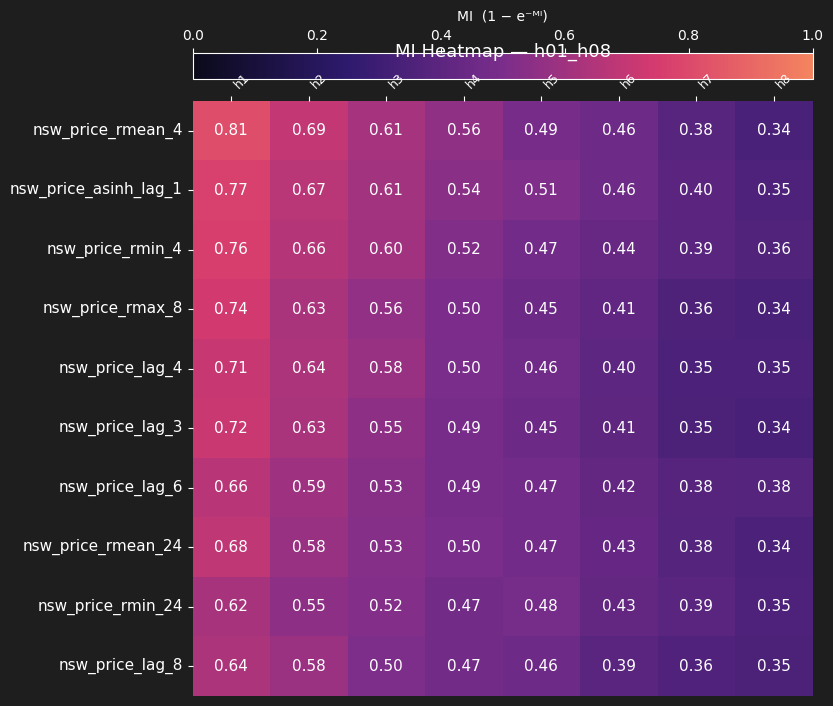


  Window h09_h16  —  424 unique features


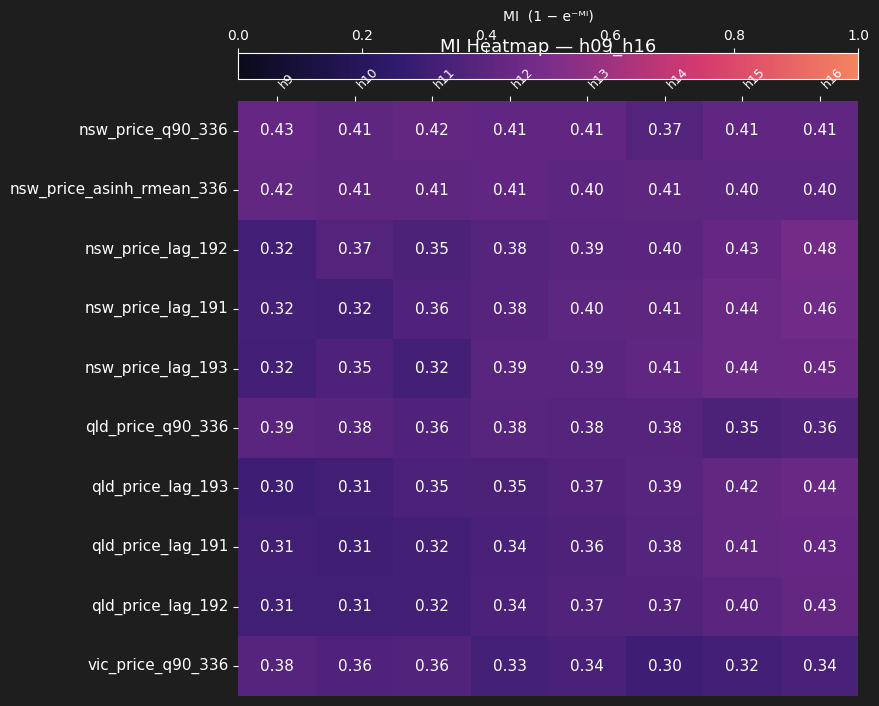


  Window h17_h24  —  423 unique features


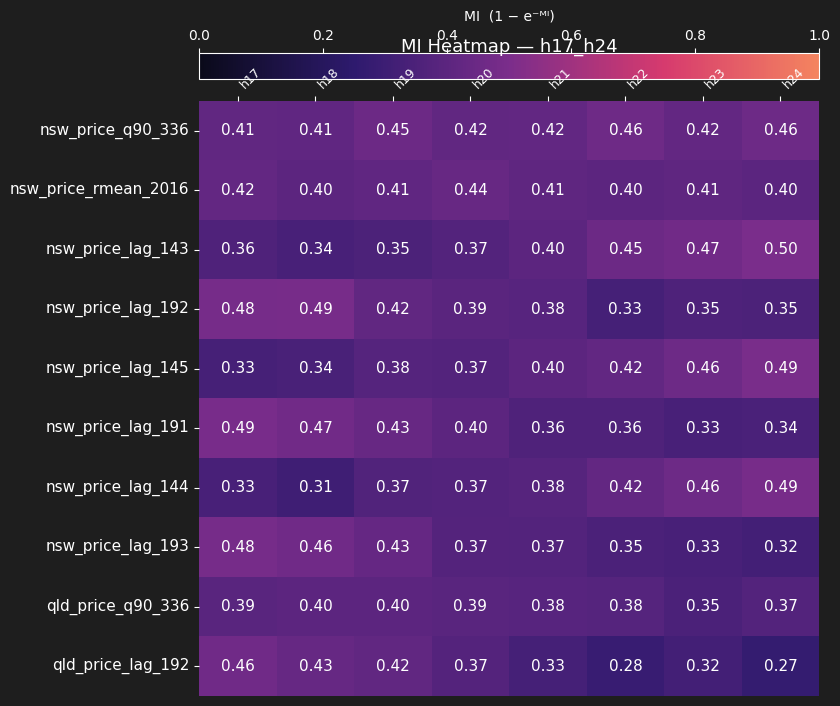


  Window h25_h32  —  425 unique features


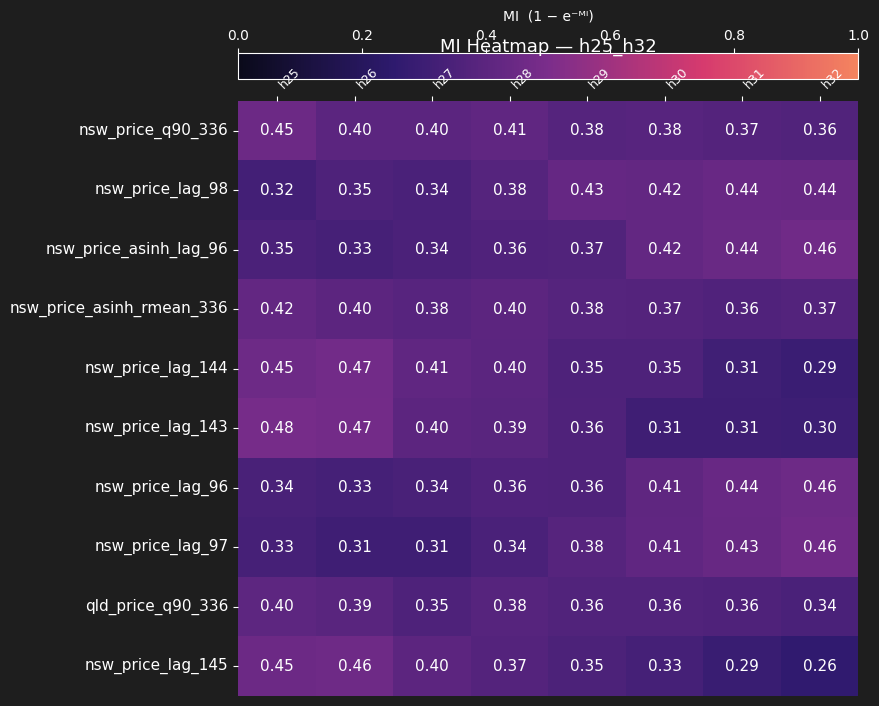


  Window h33_h40  —  421 unique features


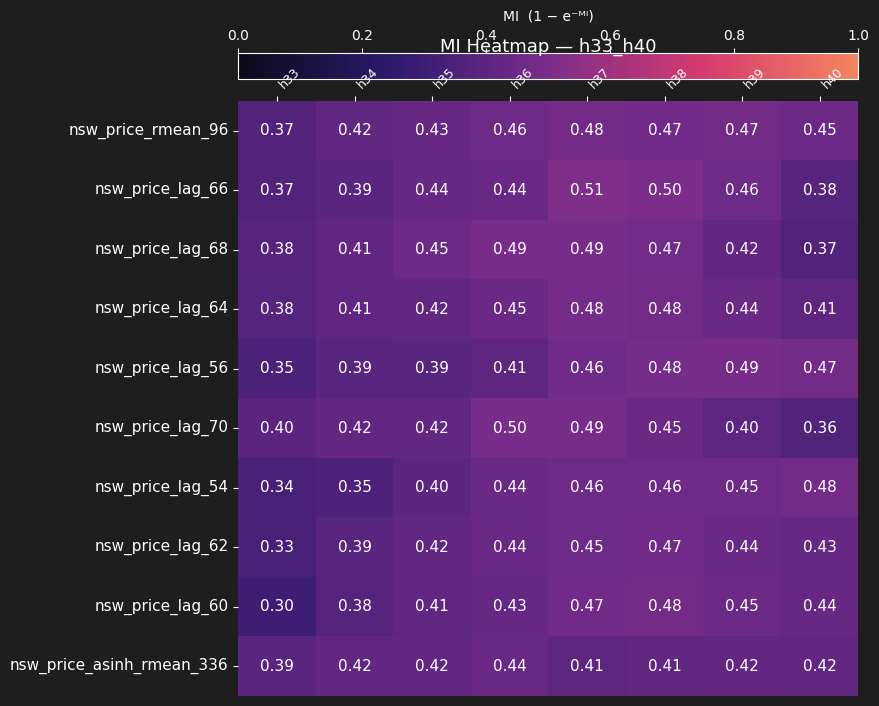


  Window h41_h48  —  424 unique features


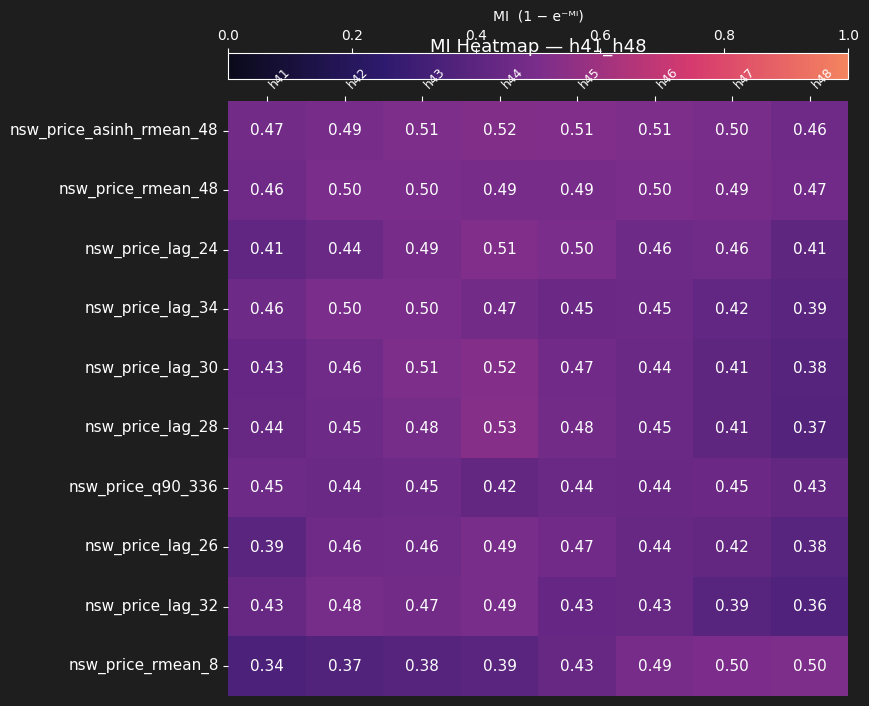


  Window h49_h56  —  421 unique features


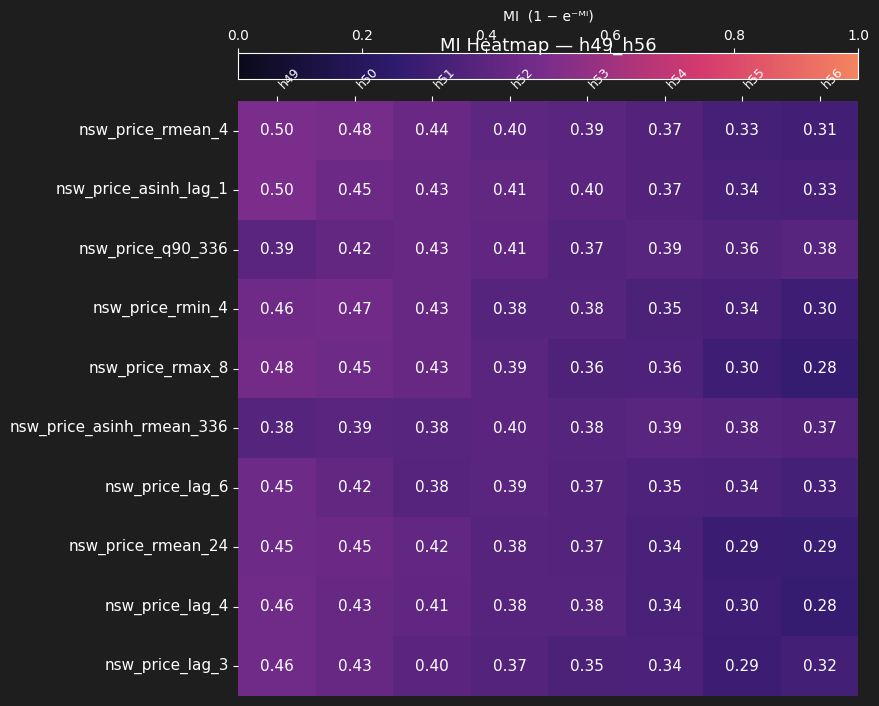


  Window h57_h64  —  420 unique features


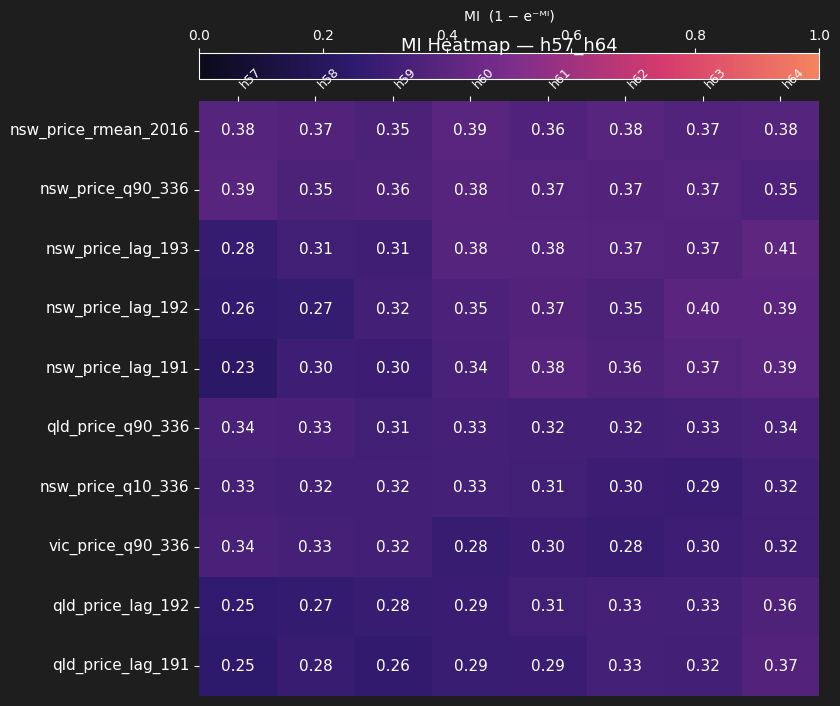


  Window h65_h72  —  421 unique features


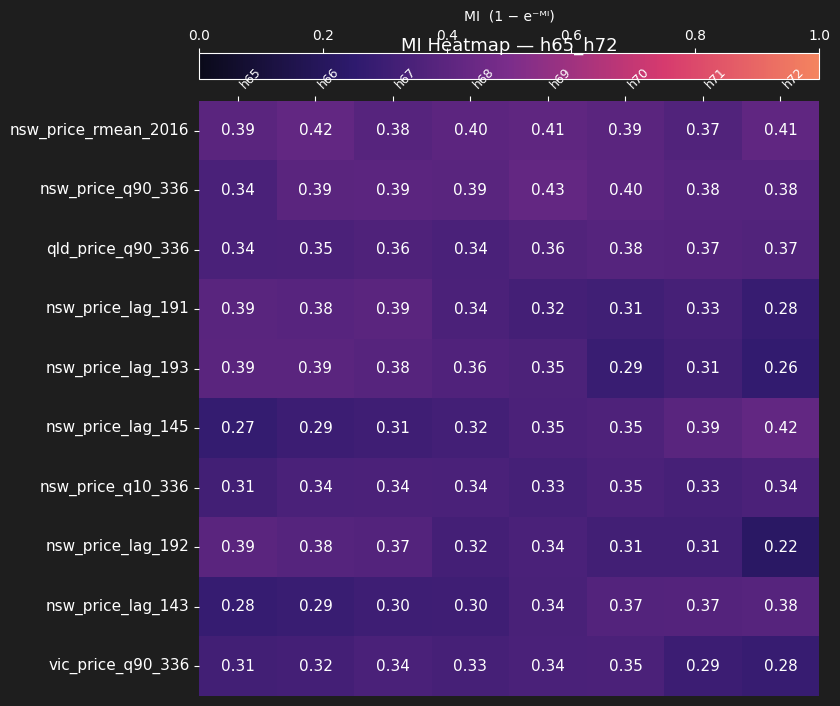


  Window h73_h80  —  419 unique features


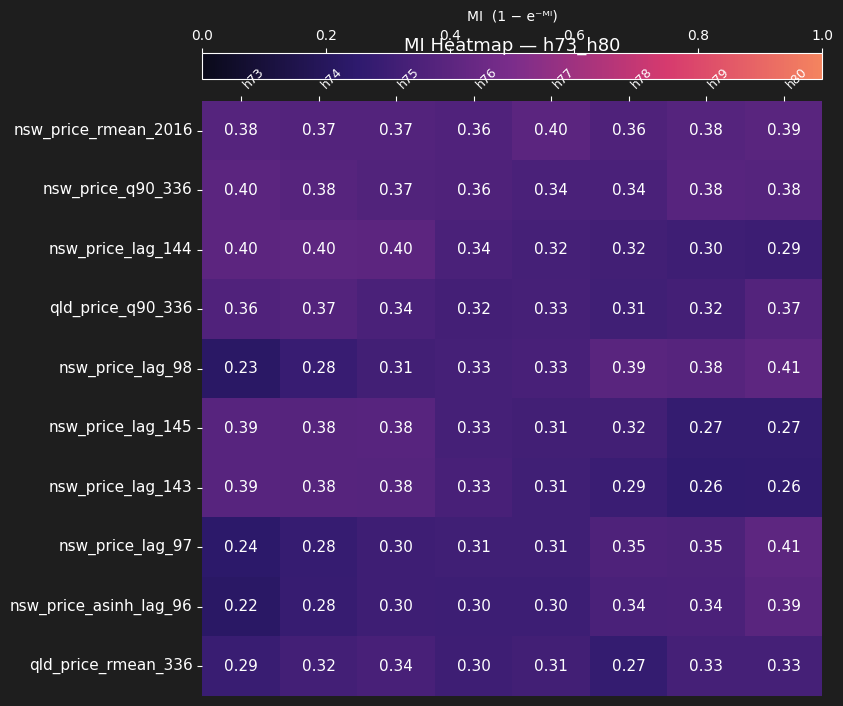


  Window h81_h88  —  424 unique features


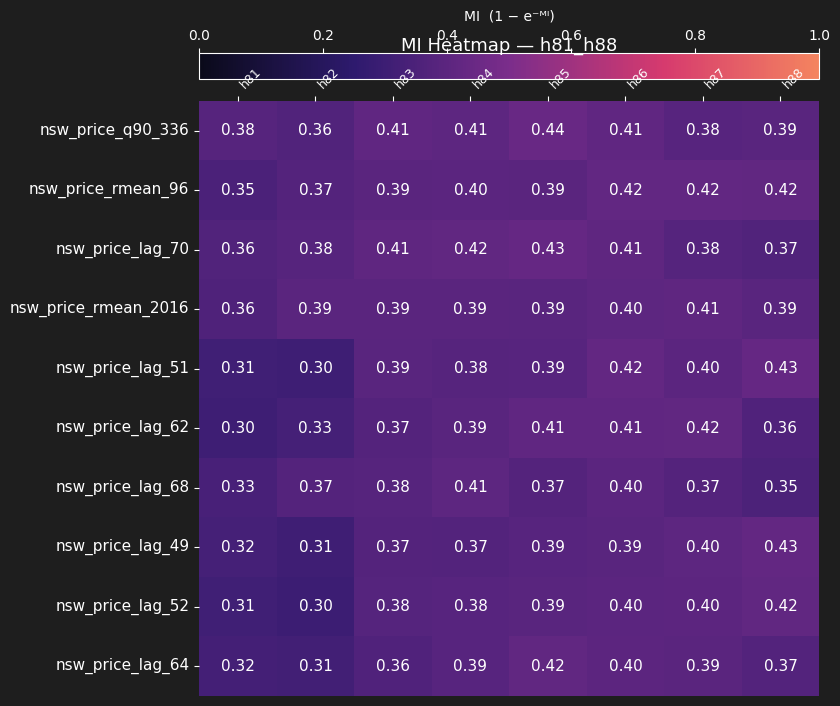


  Window h89_h96  —  424 unique features


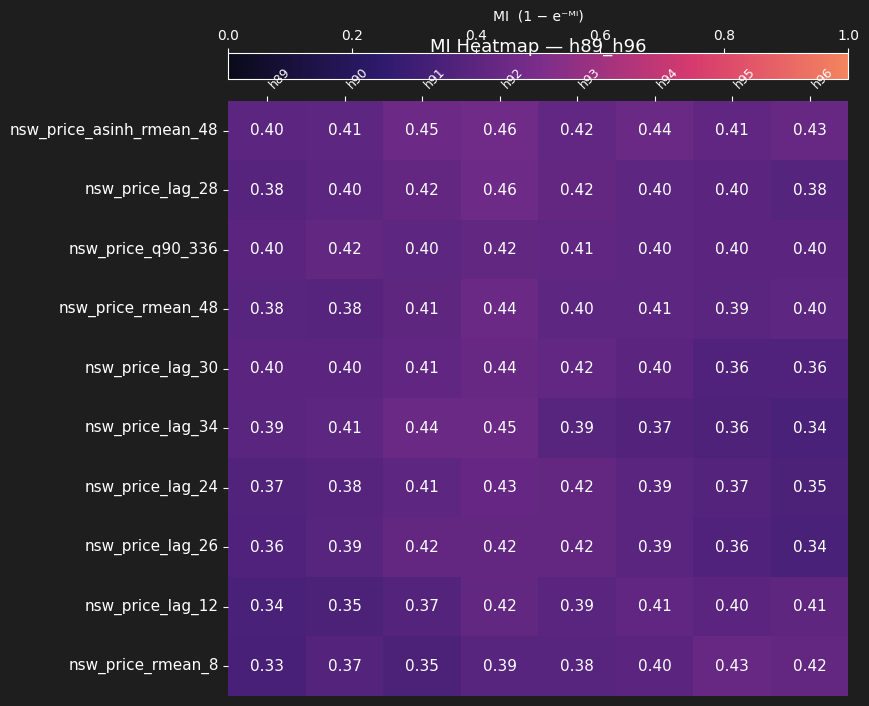

In [77]:
BUCKET_SIZE = 30 // 5  # 5-min intervals per 30-min bucket
window_best_k = {}

for w_idx, (label, feats) in enumerate(window_selections.items()):
    col_start_w = w_idx * HORIZONS_PER_WINDOW
    col_end_w   = col_start_w + HORIZONS_PER_WINDOW

    # MI matrix sliced to this window's unique features, sorted by window MI, normalised
    mi_win      = window_mi_matrices[label].loc[feats]
    mi_win      = mi_win.loc[mi_win.mean(axis=1).sort_values(ascending=False).index]
    mi_win_norm = 1 - np.exp(-mi_win)

    print(f"\n{'='*64}\n  Window {label}  —  {len(feats)} unique features\n{'='*64}")

    # Heatmap
    mi_matrix_visual(mi_win_norm, top_n=10, max_display_cols=8,
                     title=f"MI Heatmap — {label}")

    # # Elbow
    # elbow_w = plot_cumulative_mi_elbow(mi_win_norm,
    #                                    title=f"Cumulative MI — {label}")

    # # Validation curve — target = mean over this window's 5-min target columns
    # win_target_cols = target_cols[col_start_w * BUCKET_SIZE : col_end_w * BUCKET_SIZE]
    # best_k_w = plot_validation_curve(
    #     features=features,
    #     targets=future_prediction_targets[win_target_cols],
    #     mi_matrix_normalised=mi_win_norm,
    #     elbow_rank=elbow_w,
    #     n_splits=5,
    #     title=f"Validation Curve — {label}",
    # )
    # window_best_k[label] = best_k_w



In [ ]:
# Update window_features.parquet with is_selected (top best_k per window)
df_windows = pd.read_parquet(windows_path)
df_windows["best_k"]      = df_windows["window"].map(window_best_k)
df_windows["is_selected"] = df_windows["rank_in_window"] <= df_windows["best_k"]
df_windows.to_parquet(windows_path, index=False)

print(f"Updated {windows_path} with is_selected")
for lbl, k in window_best_k.items():
    n_sel = (df_windows[df_windows["window"] == lbl]["is_selected"]).sum()
    print(f"  {lbl}: {n_sel} selected (best_k={k})")

df_windows.head(16)
